</br>
<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: -8px;">
    <div style="width: 50%;">
        <h2>
            <span style="color: #B30033;">▍</span>Práctica 2:
        </h2>
        <h1 style="margin-top: -10px;">
            Aprendizaje y selección de modelos de clasificación
        </h1>
    </div>
    <div style="width: 50%; text-align: right;">
        <div style="display: flex; justify-content: space-between; align-items: flex-start; margin-top: 30px;">
            <div style="width: 20%;"></div>
            <div style="width: 80%; border-left: 2px solid #555555; padding-left: 20px;">
                <div style="margin-bottom: 20px;">
                    <p style="margin: 0; font-size: 1.4em; font-weight: bold;">
                        Minería de Datos, 2025-26
                    </p>
                </div>
                </div>
            </div>
        </div>
    </div>
</div>

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: #B30033; font-size: 1.5em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1.4em; font-weight: bold">
            Estudiantes
        </h3>
    </div>
    <ul style="list-style-type: none; padding-left: 28px; margin: 0;  font-size: 1.1em">
        <li>Alex Ortega Redondo</li>
        <li>Javier García Meneses</li>
    </ul>

</div>

In [8]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

## 1. Introducción

El objetivo de esta práctica es construir sobre el trabajo realizado en la Práctica 1. Se aplicarán y compararán diversos modelos de clasificación supervisada, utilizando validación cruzada y ajuste de hiperparámetros, para seleccionar el modelo más eficaz en la predicción del abandono estudiantil.

Para ello, continuaréis utilizando los mismos conjuntos de datos de la práctica anterior (`uclm_student_train.csv` y `uclm_student_test.csv`). El `Pipeline` de preprocesamiento desarrollado en la Práctica 1 servirá como base para el entrenamiento de los modelos (aunque podéis modificarlo).

Tendréis que explorar y evaluar los modelos de clasificación introducidos en el notebook complementario (`Material Práctica 2 - Modelos y Selección.ipynb`), junto con al menos un algoritmo adicional investigado de forma independiente, el cual tendréis que explicar más detalladamente. El rendimiento se evaluará rigurosamente mediante validación cruzada, y técnicas como `GridSearchCV` para encontrar la configuración óptima de hiperparámetros.

El modelo final seleccionado se utilizará para generar predicciones en el conjunto de prueba y participar en la competición de Kaggle.

## 2. Carga de Datos y Preprocesamiento Base




Como punto de partida, cargaremos los datos igual que en la Práctica 1:

In [3]:
pd.set_option('display.max_columns', None)

df_train = pd.read_csv('uclm_student_train.csv')
df_train

,id,nombre,nacimiento,provincia,residencia_id,trabaja,horas_trabajo,bachillerato,nota_acceso,modalidad,creditos_a1,superados_a1,nota_s1,satisfaccion,horas_moodle,posts_foro,uso_biblioteca,eventos,tutorias,comentarios,numero_fav,talla_zapato,color_fav,meses_matriculado,grupo_trabajo,abandono
0,TO-2010-GCA531,Graciano Cano Alsina,1992-05-06,Albacete,E1-P02-H04,0,NaN,Científico,6.08,Tiempo completo,60,60,8.16,4.32,~7.2 horas,2,11,1,4,relacion correcto con compañeros,71,43,Azul oscuro,6,GR10335,1
1,CU-2016-MBP239,María Belén Polo,1998-10-31,Cuenca,E2-P03-H06,0,NaN,CIENCIAS PURAS,8.12,Tiempo completo,60,60,9.09,4.05,~11.8 horas,13,2,2,0,Uso normal de la plataforma Moodle,22,38,Coral claro,6,GR13813,0
2,CR-2010-JS201,Judith Sáenz,1992-03-11,Ciudad Real,NaN,0,NaN,Ciencias Puras,10.59,Tiempo completo,60,54,7.99,3.88,~8.8 horas,6,14,2,3,NaN,69,37,Violeta oscuro,6,GR02505,0
3,TO-2016-CDB602,Casandra de Bautista,1998-11-03,Toledo,E1-P04-H18,0,NaN,Humanidades,7.85,Tiempo completo,60,48,7.27,3.81,~8.7 horas,0,0,2,3,Relacion adecuado con compañeros.,3,34,Rosa profundo,6,GR14887,0
4,AB-2011-CAA364,Carlito Alvarado Anaya,1993-12-22,Albacete,NaN,0,NaN,ECONÓMICO,10.23,Tiempo completo,60,60,8.45,4.08,~9.6 horas,16,6,2,3,ha mejorado notablemente en asignaturas troncales,19,39,Coral claro,5,GR09244,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40540,AB-2011-CB913,Cecilia Bosch,1993-04-14,Albacete,NaN,0,NaN,CIENCIAS SOCIALES,8.64,Tiempo completo,60,36,5.52,2.94,~1.1h,8,0,3,0,NaN,23,39,Rojo violeta medio,6,GR15949,1
40541,TO-2011-WRL313,Wilfredo Roda Lerma,1987-11-12,Toledo,NaN,1,NaN,Económico,10.59,Tiempo completo,60,60,9.00,4.05,~11.5 horas,8,2,3,2,NaN,76,40,Amarillo,6,GR11547,0
40542,CR-2017-JA946,Javi Acuña,1999-09-05,Ciudad Real,NaN,0,NaN,TECNOLÓGICO,10.41,Tiempo completo,60,54,NaN,3.52,~5.1 horas,3,8,4,4,Expresa dudas sobre continuar los estudios.,24,40,Gris claro,4,GR00625,1
40543,AB-2010-TRM306,Teresita Rodrigo Morera,1992-06-23,Albacete,NaN,0,NaN,Económico,10.15,Tiempo completo,60,54,7.36,3.70,~8.0 horas,10,3,4,0,NaN,39,38,Azul real,6,GR06859,0


Y a partir de aquí reutilizaremos el pipeline de preprocesamiento definido en la Práctica 1. Podéis modificarlo como creáis conveniente, ya que a la hora de trabajar con los modelos podéis seguir descubriendo información de las variables. 

Es fundamental encapsular todas las transformaciones (imputación, escalado, codificación, ingeniería de características) desarrolladas previamente en un único `Pipeline` o `ColumnTransformer` para aplicarlo consistentemente antes de cada modelo.

*Recordatorio: Asegúrate de que tu pipeline de preprocesamiento maneja adecuadamente todos los tipos de variables y artefactos presentes en los datos (`numéricas`, `categóricas`, `fechas`, `texto`, `valores faltantes`, etc.)*.

# 3.- Análisis Exploratorio de los datos (EDA)

Con respecto a la práctica anterior, hemos creado algunas variables nuevas que vamos a analizar brevemente.

#### Nota baja

In [4]:
df_train['categoria_nota'] = pd.cut(df_train['nota_s1'], bins=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], labels=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], right=False)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_62092\139111274.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_train.groupby('categoria_nota')['abandono'].mean().plot.bar(ax=ax[0],color=sns.color_palette("crest")[3],edgecolor="black")


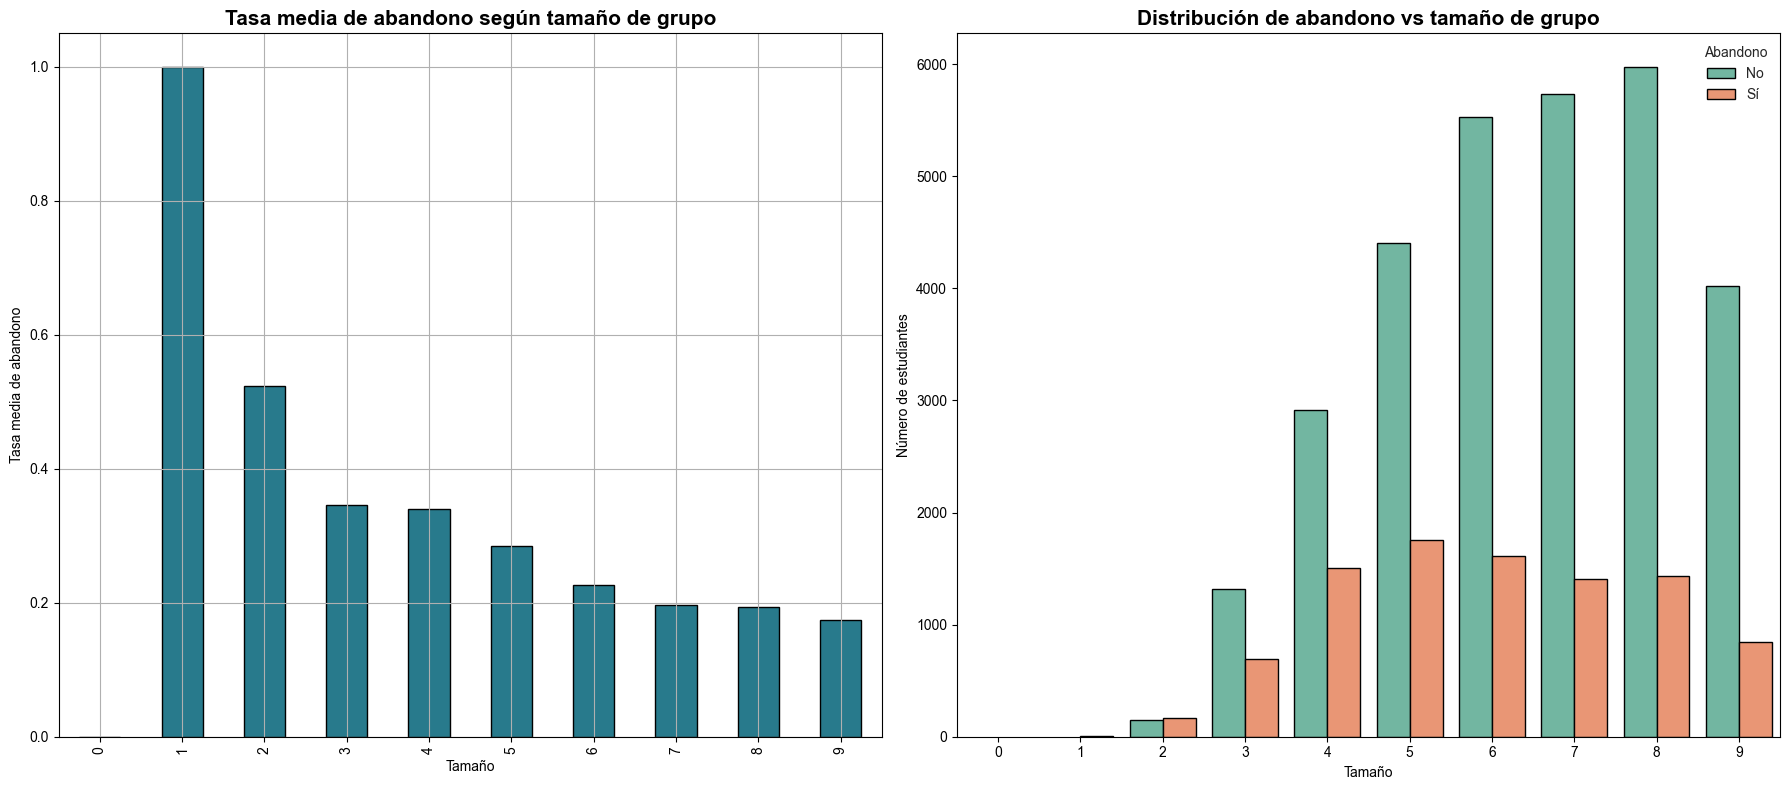

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 8))
plt.style.use("seaborn-v0_8-whitegrid")

df_train.groupby('categoria_nota')['abandono'].mean().plot.bar(ax=ax[0],color=sns.color_palette("crest")[3],edgecolor="black")
ax[0].set_title("Tasa media de abandono según nota", fontsize=15, weight="bold")
ax[0].set_xlabel("Nota")
ax[0].set_ylabel("Tasa media de abandono")

sns.countplot(x='categoria_nota',hue='abandono',data=df_train,ax=ax[1],palette="Set2",edgecolor="black")
ax[1].set_title("Distribución de abandono vs nota", fontsize=15, weight="bold")
ax[1].set_xlabel("Nota")
ax[1].set_ylabel("Número de estudiantes")
ax[1].legend(title="Abandono", labels=["No", "Sí"])

plt.tight_layout()
plt.show()

Hemos creado una variable binaria que nos indica si un estudiante tiene una nota baja o no. En nuestro caso, como condición hemos puesto que sea menor que 2. Como podemos ver en la gráfica, tanto la tasa de los estudiantes que tienen de nota un 1 como de los que tienen de nota un 2 es muy alta con respecto a las otras. 

#### Grupo tamaño 1

In [9]:
dicc = (df_train['grupo_trabajo'].value_counts().sort_values()).to_dict()
df_train['tamaño_grupo'] = df_train['grupo_trabajo'].map(dicc)
df_train['grupo_tamaño_1'] = np.where(df_train['tamaño_grupo'] == 1, 1, 0)

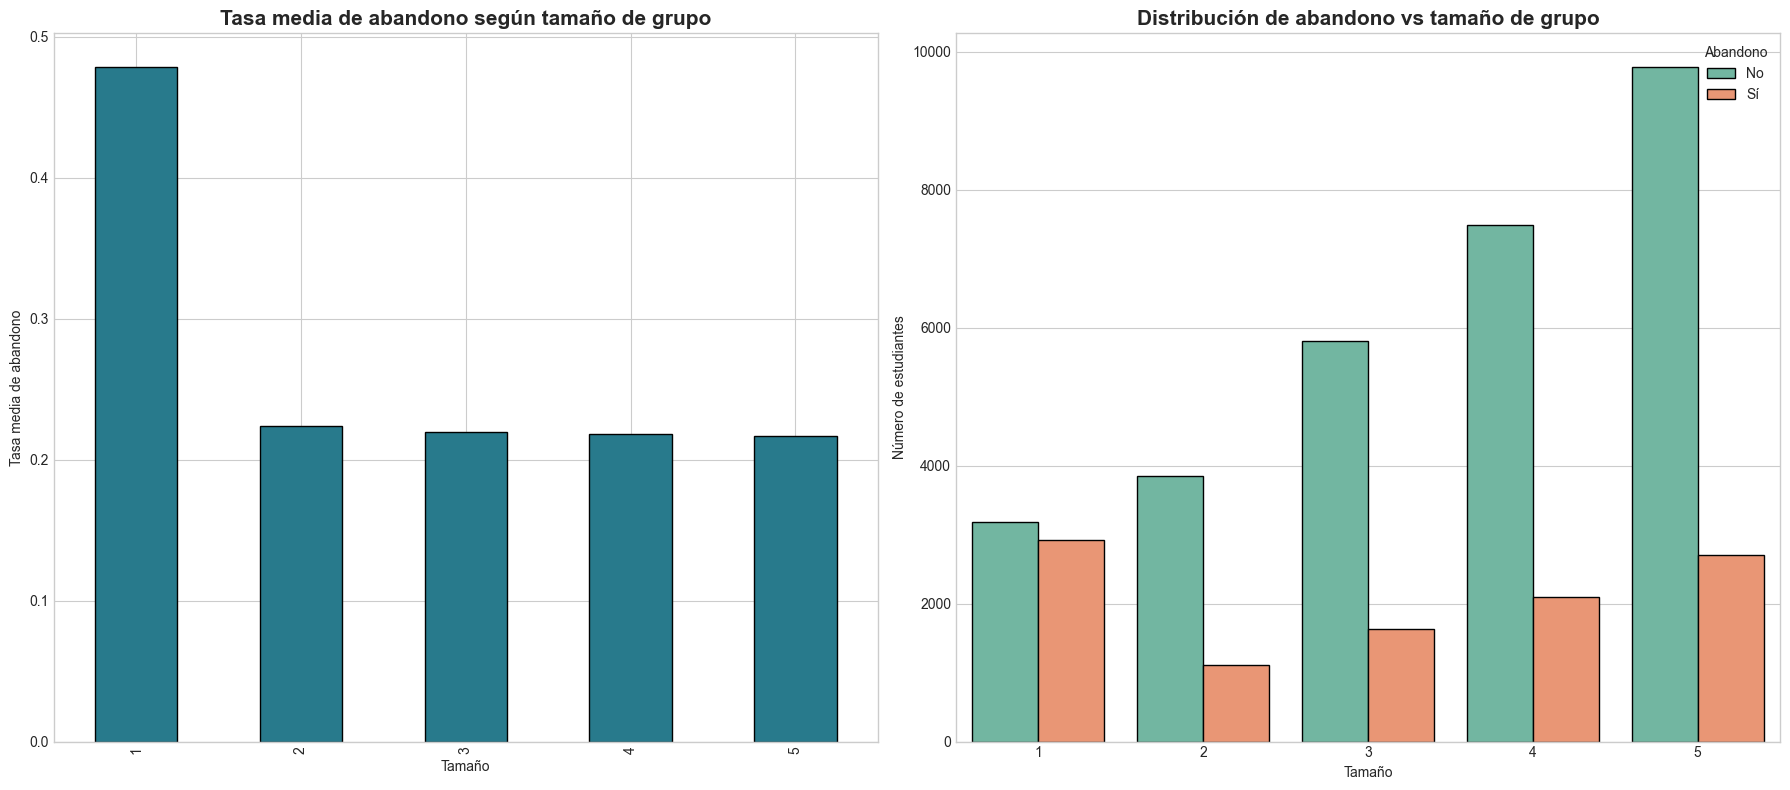

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(18, 8))
plt.style.use("seaborn-v0_8-whitegrid")

df_train.groupby('tamaño_grupo')['abandono'].mean().plot.bar(ax=ax[0],color=sns.color_palette("crest")[3],edgecolor="black")
ax[0].set_title("Tasa media de abandono según tamaño de grupo", fontsize=15, weight="bold")
ax[0].set_xlabel("Tamaño")
ax[0].set_ylabel("Tasa media de abandono")

sns.countplot(x='tamaño_grupo',hue='abandono',data=df_train,ax=ax[1],palette="Set2",edgecolor="black")
ax[1].set_title("Distribución de abandono vs tamaño de grupo", fontsize=15, weight="bold")
ax[1].set_xlabel("Tamaño")
ax[1].set_ylabel("Número de estudiantes")
ax[1].legend(title="Abandono", labels=["No", "Sí"])

plt.tight_layout()
plt.show()

Hemos creado una variable binaria que nos indica si un estudiante está solo en el grupo de trabajo o no. Como podemos ver en la gráfica, la tasa de abandono de los estudiantes que están solos en el grupo de trabajo es muy alta, mientras que para los demás se mantienen casi iguales. 

#### Horas de trabajo 40

In [11]:
df_train['horas_trabajo_40'] = np.where(df_train['horas_trabajo'] == 40, 1, 0)

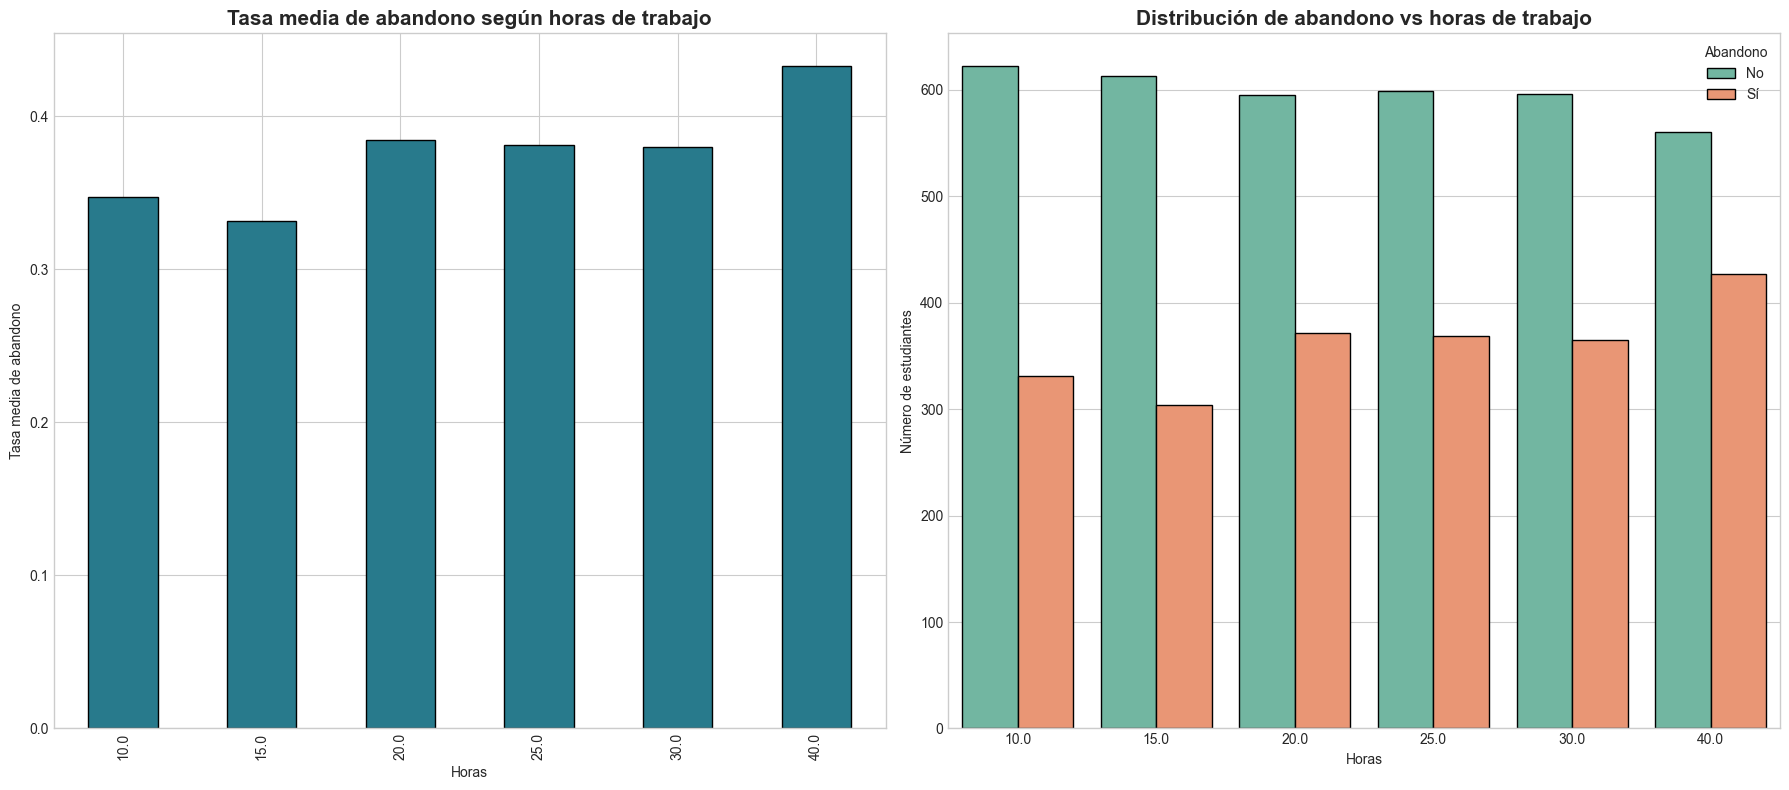

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(18, 8))
plt.style.use("seaborn-v0_8-whitegrid")

df_train.groupby('horas_trabajo')['abandono'].mean().plot.bar(ax=ax[0],color=sns.color_palette("crest")[3],edgecolor="black")
ax[0].set_title("Tasa media de abandono según horas de trabajo", fontsize=15, weight="bold")
ax[0].set_xlabel("Horas")
ax[0].set_ylabel("Tasa media de abandono")

sns.countplot(x='horas_trabajo',hue='abandono',data=df_train,ax=ax[1],palette="Set2",edgecolor="black")
ax[1].set_title("Distribución de abandono vs horas de trabajo", fontsize=15, weight="bold")
ax[1].set_xlabel("Horas")
ax[1].set_ylabel("Número de estudiantes")
ax[1].legend(title="Abandono", labels=["No", "Sí"])

plt.tight_layout()
plt.show()

Hemos creado una variable binaria que nos indica si un estudiante trabaja 40 horas o no. Como podemos ver en la gráfica, la tasa de abandono de los estudiantes que trabajan 40 horas es mayor que las tasas de las demás horas. 